# American Pika (*Ochotona princeps*) — Presence/Absence Climate Data: Exploratory Data Analysis

This notebook explores two datasets used for species distribution modeling (SDM) of the American pika:

- **`presence_pika_final_with_extraTPDSIandSnow__1_.csv`** — occurrence ("detected") records aggregated from museum collections and citizen-science platforms (GBIF-style occurrence data).
- **`absence_pika_final_with_extraTPDSIandSnow.csv`** — targeted resurvey sites where pikas were **not** found, classified as *recent absence*, *long absence*, or *extirpated (Great Basin)*.

Both files share a common set of environmental predictors: the standard WorldClim bioclimatic variables (BIO1, BIO4, BIO5, BIO6, BIO12, BIO15), temperature/snow summaries, and a set of supplementary variables — hence the `_extraTPDSIandSnow` suffix — describing drought severity (PDSI) and snow-water-equivalent (SWE), each also reported for "the year before" the record.

**Goal of this notebook:** understand the structure, quality, and key patterns in the data — class balance, missingness, spatial/temporal coverage, univariate and bivariate distributions, correlation structure, and outliers — as groundwork for downstream SDM work. No modeling is performed here.

## Contents
1. [Setup](#1.-Setup)
2. [Loading the Data](#2.-Loading-the-Data)
3. [Structure & Schema](#3.-Structure-&-Schema)
4. [Missing Data](#4.-Missing-Data)
5. [Duplicates & Record Provenance](#5.-Duplicates-&-Record-Provenance)
6. [Building a Combined Analysis Frame](#6.-Building-a-Combined-Analysis-Frame)
7. [Class Balance (Target Variable)](#7.-Class-Balance-(Target-Variable))
8. [Temporal Distribution](#8.-Temporal-Distribution)
9. [Spatial Distribution](#9.-Spatial-Distribution)
10. [Univariate Analysis — Core Bioclimatic Variables](#10.-Univariate-Analysis-—-Core-Bioclimatic-Variables)
11. [Univariate Analysis — Snow & Drought (PDSI) Variables](#11.-Univariate-Analysis-—-Snow-&-Drought-(PDSI)-Variables)
12. [Presence vs. Absence — Statistical Comparison](#12.-Presence-vs.-Absence-—-Statistical-Comparison)
13. [Correlation Structure](#13.-Correlation-Structure)
14. [Pairwise Relationships](#14.-Pairwise-Relationships)
15. [Outliers & Data-Quality Deep Dive](#15.-Outliers-&-Data-Quality-Deep-Dive)
16. [Summary of Key Findings](#16.-Summary-of-Key-Findings)


## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

# Display settings
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

# Plot style
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

# A colorblind-safe palette (Okabe-Ito) used consistently for the four status classes
STATUS_COLORS = {
    'detected':              '#0072B2',   # blue            -> presence
    'recent absence':        '#E69F00',   # orange          -> absence (recent)
    'long absence':          '#D55E00',   # vermillion      -> absence (long-standing)
    'extirpated_GreatBasin': '#CC79A7',   # reddish purple  -> absence (locally extinct)
}
STATUS_ORDER = ['detected', 'recent absence', 'long absence', 'extirpated_GreatBasin']
DATASET_COLORS = {'presence': STATUS_COLORS['detected'], 'absence': STATUS_COLORS['long absence']}

print('Setup complete.')

Setup complete.


## 2. Loading the Data

The presence file is read with `low_memory=False` — it mixes numeric and text values in the `units` column, which otherwise triggers pandas' chunked dtype-guessing warning.

In [4]:
PRESENCE_PATH = 'presence_pika_final_with_extraTPDSIandSnow.csv'
ABSENCE_PATH  = 'absence_pika_final_with_extraTPDSIandSnow.csv'

presence_df = pd.read_csv(PRESENCE_PATH, low_memory=False)
absence_df  = pd.read_csv(ABSENCE_PATH)

print(f'Presence records: {presence_df.shape[0]:,} rows x {presence_df.shape[1]} columns')
print(f'Absence records:  {absence_df.shape[0]:,} rows x {absence_df.shape[1]} columns')

Presence records: 17,949 rows x 46 columns
Absence records:  225 rows x 43 columns


## 3. Structure & Schema

In [5]:
presence_df.head()

,id,lat,long,year,status,status_description,elevation,patch_size,slope,units,slope_deg,bio1_temp_mean_annual,bio4_seasonality_temp,bio5_temp_max_warm,bio6_temp_min_cold,bio12_precip_annual,bio15_seasonality_precip,months_with_snow,winter_precip,estim_snow,months_above_25,max_temperature,summer_max_temperature,winter_max_temperature,min_temperature,summer_min_temperature,winter_min_temperature,Worst_drought,Worst_drought_YearBefore,AnnualMean_PDSI,AnnualMean_YearBefore_PDSI,summerMean_PDSI,summerMean_YearBefore_PDSI,months_with_drought,months_with_drought_YearBefore,winterMean_PDSI,winterMean_YearBefore_PDSI,Max_snow,Max_snow_YearBefore,AnnualMean_swe,AnnualMean_YearBefore_swe,coldSeasonMean_swe,coldSeasonMean_YearBefore_swe,months_with_snow_YearBefore,springMean_swe,springMean_YearBefore_swe
0,00486fbc-9219-4c3a-b813-abf74b71b927,36.613290,-105.319920,1925.0,2.0,detected,2663.0,NaN,NaN,NaN,7.55,4.004500,763.396118,23.848000,-15.244,565.0,39.174522,5.0,85.0,171.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,00d40a07-1301-3014-e9ae-951702849940,49.083300,-117.867000,1929.0,2.0,detected,1670.0,NaN,NaN,NaN,25.51,4.935000,787.047058,24.091999,-8.784,780.0,27.080744,4.0,234.0,325.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,012ca8c4-8e7c-48fb-825e-c5b5408f19b7,45.620290,-115.701685,1939.0,2.0,detected,2518.0,NaN,NaN,NaN,33.85,0.118500,689.189087,20.544001,-14.932,703.0,26.800249,6.0,216.0,405.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0183cebf-45cd-5cd4-7890-02fc877e0ad7,51.916700,-123.033000,1953.0,2.0,detected,702.0,NaN,NaN,NaN,14.64,3.864500,921.523621,23.392000,-16.084,326.0,40.333080,5.0,69.0,104.0,0.0,22.2,22.2,1.8,-19.3,4.4,-19.3,-1.4,-2.4,0.401667,1.045,1.836667,2.28,0.0,3.0,-1.14,0.663333,116.7,134.9,33.408333,35.666667,62.633333,68.283333,6.0,47.266667,51.066667
4,021a6830-6eeb-4d83-b8c2-c434ec1ac564,45.008079,-117.192457,1937.0,2.0,detected,1435.0,NaN,NaN,NaN,15.90,3.628833,729.984985,24.716000,-10.612,556.0,29.718885,5.0,172.0,277.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
absence_df.head()

,id,lat,long,year,status,status_description,elevation,slope_deg,bio1_temp_mean_annual,bio4_seasonality_temp,bio5_temp_max_warm,bio6_temp_min_cold,bio12_precip_annual,bio15_seasonality_precip,months_with_snow,winter_precip,estim_snow,months_above_25,max_temperature,summer_max_temperature,winter_max_temperature,min_temperature,summer_min_temperature,winter_min_temperature,Worst_drought,Worst_drought_YearBefore,AnnualMean_PDSI,AnnualMean_YearBefore_PDSI,summerMean_PDSI,summerMean_YearBefore_PDSI,months_with_drought,months_with_drought_YearBefore,winterMean_PDSI,winterMean_YearBefore_PDSI,Max_snow,Max_snow_YearBefore,AnnualMean_swe,AnnualMean_YearBefore_swe,coldSeasonMean_swe,coldSeasonMean_YearBefore_swe,months_with_snow_YearBefore,springMean_swe,springMean_YearBefore_swe
0,4 (near A1b),40.003100,-120.174530,2019.0,0.0,long absence,2150.059200,6.65,7.051167,708.752808,27.848000,-7.508,489.0,56.275841,4.0,203.0,203.0,2.0,29.0,29.0,5.3,-8.5,5.9,-8.5,-1.53,-2.19,1.619167,-0.340000,2.003333,0.496667,0.0,1.0,-0.046667,-1.830000,315.2,118.1,60.275000,14.358333,120.550000,28.500000,3.0,84.033333,39.800000
1,BLUE,48.277196,-116.827214,2016.0,0.0,long absence,678.000000,0.00,6.725000,809.150330,27.208000,-7.324,800.0,41.130657,3.0,290.0,290.0,2.0,28.2,28.2,6.5,-9.0,8.1,-9.0,-4.43,-5.24,-2.885000,-3.755833,-4.243333,-4.973333,9.0,9.0,-1.683333,-2.480000,272.4,232.8,31.966667,39.241667,63.933333,78.483333,4.0,0.200000,0.000000
2,DAMT,48.506807,-114.981014,2016.0,0.0,long absence,1514.000000,13.52,3.885000,810.145203,24.760000,-11.600,641.0,25.275459,4.0,195.0,314.0,1.0,25.6,25.6,4.8,-13.5,4.2,-13.5,-3.65,-4.65,-2.382500,-3.109167,-3.233333,-4.363333,9.0,9.0,-1.676667,-1.710000,215.1,225.4,45.866667,56.091667,91.733333,112.183333,4.0,20.000000,2.466667
3,EGMT_17_OHP1,39.439296,-120.536311,2019.0,1.0,recent absence,2296.973073,13.22,5.570000,671.297363,24.884001,-7.664,1205.0,75.337685,5.0,579.0,748.0,1.0,26.1,26.1,5.0,-9.4,5.0,-9.4,-1.99,-2.45,1.490000,-0.480833,2.536667,-0.223333,0.0,3.0,-0.490000,-0.810000,938.1,412.6,191.150000,56.441667,379.433333,109.733333,5.0,318.433333,143.833333
4,ENGMTN1_17_UOT,39.461561,-120.551210,2019.0,0.0,long absence,2083.300067,4.76,6.207500,651.554810,25.355999,-6.760,1232.0,76.075615,4.0,593.0,593.0,1.0,26.6,26.6,6.1,-8.7,5.4,-8.7,-2.02,-2.43,1.687500,-0.480833,2.603333,-0.226667,1.0,3.0,0.153333,-0.826667,733.8,351.4,143.866667,39.966667,286.066667,78.483333,4.0,247.933333,120.033333


Comparing the two schemas directly:

In [7]:
shared_cols = sorted(set(presence_df.columns) & set(absence_df.columns))
presence_only_cols = sorted(set(presence_df.columns) - set(absence_df.columns))
absence_only_cols = sorted(set(absence_df.columns) - set(presence_df.columns))

print(f'Shared columns ({len(shared_cols)}):')
print(shared_cols)
print()
print(f'Presence-only columns ({len(presence_only_cols)}): {presence_only_cols}')
print(f'Absence-only columns  ({len(absence_only_cols)}): {absence_only_cols}')
print()
presence_df.dtypes.value_counts().rename('column count').to_frame()

Shared columns (43):
['AnnualMean_PDSI', 'AnnualMean_YearBefore_PDSI', 'AnnualMean_YearBefore_swe', 'AnnualMean_swe', 'Max_snow', 'Max_snow_YearBefore', 'Worst_drought', 'Worst_drought_YearBefore', 'bio12_precip_annual', 'bio15_seasonality_precip', 'bio1_temp_mean_annual', 'bio4_seasonality_temp', 'bio5_temp_max_warm', 'bio6_temp_min_cold', 'coldSeasonMean_YearBefore_swe', 'coldSeasonMean_swe', 'elevation', 'estim_snow', 'id', 'lat', 'long', 'max_temperature', 'min_temperature', 'months_above_25', 'months_with_drought', 'months_with_drought_YearBefore', 'months_with_snow', 'months_with_snow_YearBefore', 'slope_deg', 'springMean_YearBefore_swe', 'springMean_swe', 'status', 'status_description', 'summerMean_PDSI', 'summerMean_YearBefore_PDSI', 'summer_max_temperature', 'summer_min_temperature', 'winterMean_PDSI', 'winterMean_YearBefore_PDSI', 'winter_max_temperature', 'winter_min_temperature', 'winter_precip', 'year']

Presence-only columns (3): ['patch_size', 'slope', 'units']
Absence-o

,column count
float64,43
str,3


**Notes:**
- The two files share **43 columns** — `id`, coordinates, `year`, `status`/`status_description`, elevation/slope, the six core BIO variables, and the extended temperature, snow, and PDSI-drought variables (current year + "year before" versions).
- `patch_size`, `slope`, and `units` exist **only** in the presence file. `units` documents whether `slope` is in `percent` or `degrees` (as opposed to `slope_deg`, which is present in both files and always in degrees). Section 4 shows these three columns are almost entirely empty, so they add little value as-is.

## 4. Missing Data

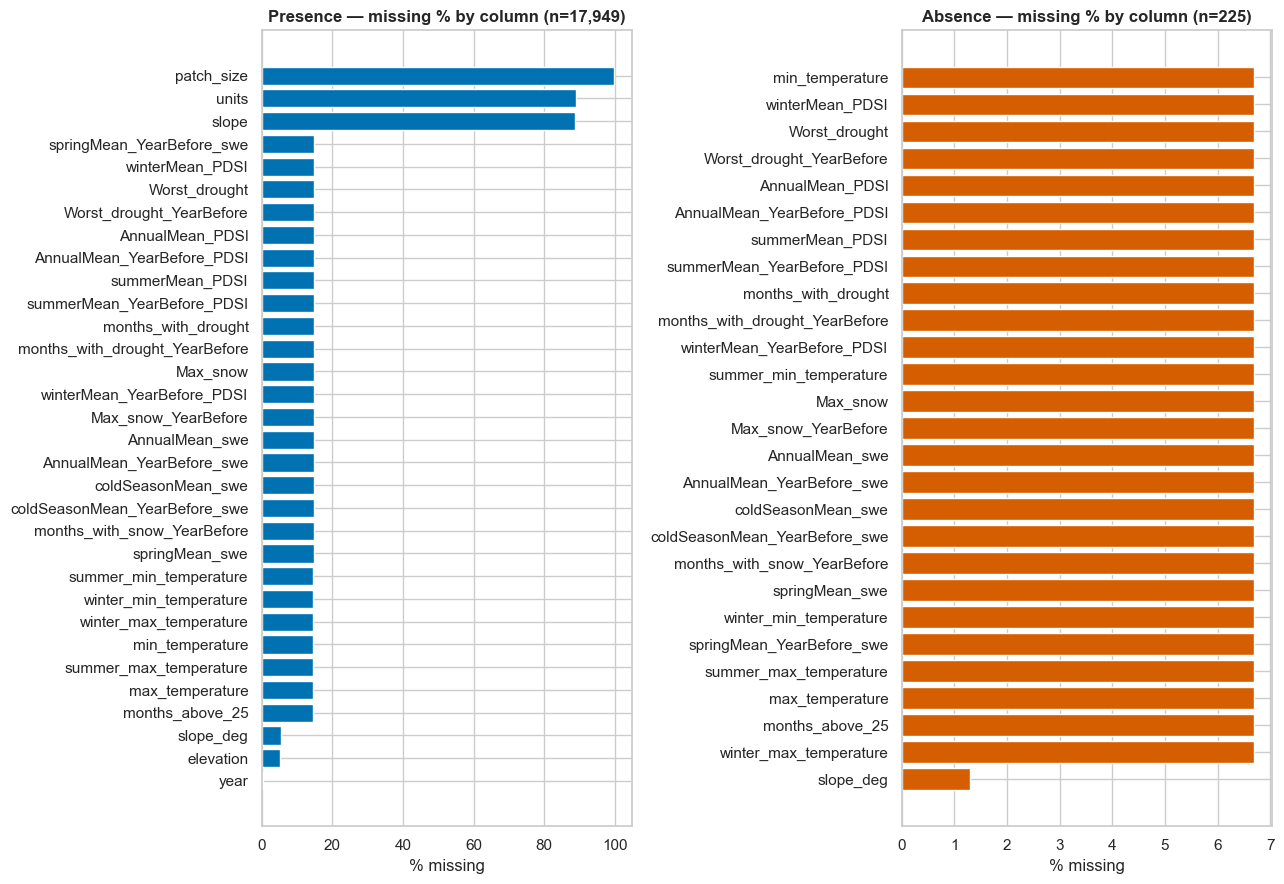

In [8]:
def missing_pct(df):
    m = df.isna().mean().mul(100).round(1).sort_values(ascending=False)
    return m[m > 0]

presence_missing = missing_pct(presence_df)
absence_missing = missing_pct(absence_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 9))

axes[0].barh(presence_missing.index[::-1], presence_missing.values[::-1], color=STATUS_COLORS['detected'])
axes[0].set_title(f'Presence — missing % by column (n={len(presence_df):,})')
axes[0].set_xlabel('% missing')

axes[1].barh(absence_missing.index[::-1], absence_missing.values[::-1], color=STATUS_COLORS['long absence'])
axes[1].set_title(f'Absence — missing % by column (n={len(absence_df):,})')
axes[1].set_xlabel('% missing')

plt.tight_layout()
plt.show()

**Reading the missingness pattern:**
- In the presence data, `patch_size` (~99.9%), `units` (~88.9%), and `slope` (~88.8%) are almost completely empty — as flagged in Section 3, these three fields are not usable in their current form.
- Two clear "bands" of missingness appear in **both** files: the snow/drought supplementary block (`*_PDSI`, `*_drought`, `*_swe`, `Max_snow*`) sits around **15% missing in presence / 7% in absence**, and the temperature-extremes block (`summer_/winter_max/min_temperature`, `months_above_25`) sits close behind. Since both bands are shared across many columns at nearly identical percentages, this looks like whole **records** falling outside the coverage of the supplementary drought/snow/temperature-extreme raster layers (e.g., grid or time-period mismatch during the join) rather than random per-cell missingness.
- The core BIO1–BIO15 variables, `months_with_snow`, `estim_snow`, and `winter_precip` are essentially complete (0% missing) in both files — these are safe to use without imputation.
- `elevation` and `slope_deg` have small amounts of missing data in presence (~5%) and almost none in absence.

This pattern matters for modeling: a listwise-deletion approach would discard ~15% of presence rows just because of the supplementary drought/snow variables. An imputation strategy (or a model choice tolerant of missing values, e.g. tree ensembles with native NaN handling) is likely preferable to dropping rows outright.

## 5. Duplicates & Record Provenance

In [9]:
print('=== Duplicate check ===')
print(f'Presence — duplicated ids: {presence_df["id"].duplicated().sum()} | unique ids: {presence_df["id"].nunique():,} / {len(presence_df):,} rows')
print(f'Absence  — duplicated ids: {absence_df["id"].duplicated().sum()} | unique ids: {absence_df["id"].nunique():,} / {len(absence_df):,} rows')
print(f'Full-row duplicates — presence: {presence_df.duplicated().sum()}, absence: {absence_df.duplicated().sum()}')
print(f'id overlap between the two files: {len(set(presence_df["id"]) & set(absence_df["id"]))}')

=== Duplicate check ===
Presence — duplicated ids: 3 | unique ids: 17,945 / 17,949 rows
Absence  — duplicated ids: 68 | unique ids: 157 / 225 rows
Full-row duplicates — presence: 0, absence: 0
id overlap between the two files: 0


No full-row duplicates exist in either file, and there is no `id` overlap between presence and absence (good — no cross-contamination between the two classes). The 68 duplicated ids in the absence file are expected: absence `id`s are **site names** (e.g. `BLUE`, `FTKL`), and the same site was resurveyed in different years, so it legitimately appears more than once. The 3 duplicated ids in presence are negligible given ~17,949 rows.

Presence `id`s look very different from absence `id`s — UUIDs, museum catalog numbers, iNaturalist URLs — which suggests the presence file aggregates several original data sources. A quick pattern match on `id` confirms this:

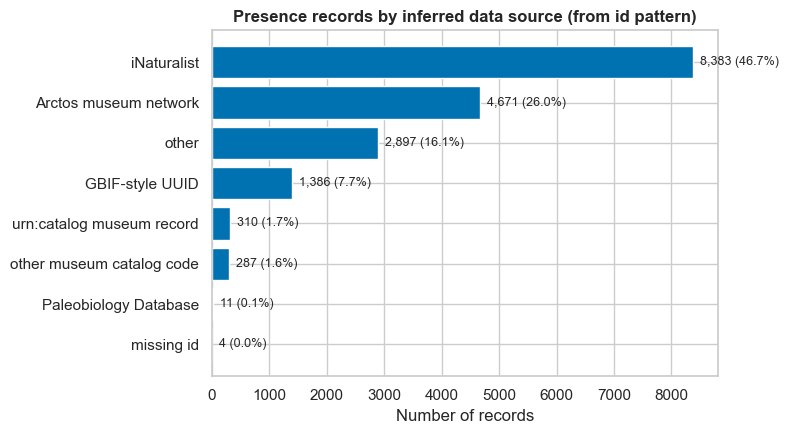

In [10]:
import re

def id_source(id_):
    if pd.isna(id_):
        return 'missing id'
    if id_.startswith('pbdb:'):
        return 'Paleobiology Database'
    if 'inaturalist.org' in id_:
        return 'iNaturalist'
    if 'arctos.database.museum' in id_:
        return 'Arctos museum network'
    if id_.startswith('urn:catalog:'):
        return 'urn:catalog museum record'
    if re.match(r'^[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}$', id_):
        return 'GBIF-style UUID'
    if ':' in id_:
        return 'other museum catalog code'
    return 'other'

id_sources = presence_df['id'].apply(id_source).value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(id_sources.index[::-1], id_sources.values[::-1], color=STATUS_COLORS['detected'])
ax.set_xlabel('Number of records')
ax.set_title('Presence records by inferred data source (from id pattern)')
for i, v in enumerate(id_sources.values[::-1]):
    ax.text(v, i, f'  {v:,} ({v/len(presence_df):.1%})', va='center', fontsize=9)
plt.tight_layout()
plt.show()

Presence data is dominated by **iNaturalist** citizen-science observations, with a large secondary contribution from the **Arctos** natural-history-museum network and a mix of other museum catalogs and GBIF-issued UUIDs. This matters for the temporal analysis in Section 8 — citizen-science platforms like iNaturalist only exist from the late 2000s onward, so we should expect presence records to skew recent, while museum specimens push the earliest dates back over a century.

## 6. Building a Combined Analysis Frame

For the comparisons in the rest of the notebook it's convenient to have one dataframe with both classes stacked, restricted to the 43 shared columns plus a `dataset` label. The three presence-only columns (`patch_size`, `slope`, `units`) are left out of this combined frame since Sections 3–4 showed they're nearly empty and don't exist in the absence data — they remain available directly in `presence_df` if needed.

In [11]:
presence_labeled = presence_df[shared_cols].copy()
presence_labeled['dataset'] = 'presence'

absence_labeled = absence_df[shared_cols].copy()
absence_labeled['dataset'] = 'absence'

combined_df = pd.concat([presence_labeled, absence_labeled], ignore_index=True)
combined_df['status_description'] = pd.Categorical(
    combined_df['status_description'], categories=STATUS_ORDER, ordered=True
)

print(f'Combined frame: {combined_df.shape[0]:,} rows x {combined_df.shape[1]} columns')
combined_df['dataset'].value_counts()

Combined frame: 18,174 rows x 44 columns


dataset
presence    17949
absence       225
Name: count, dtype: int64

## 7. Class Balance (Target Variable)

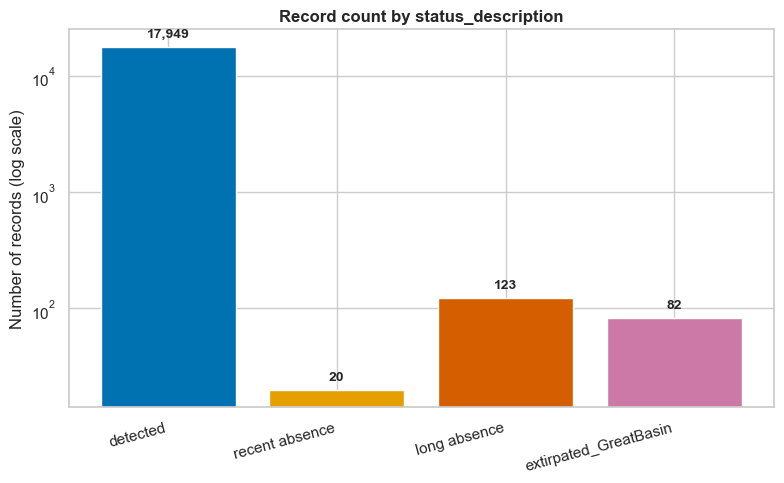

Presence : Absence ratio  = 79.8 : 1
Presence records: 17,949 (98.8% of combined data)
Absence records:  225 (1.2% of combined data)


In [12]:
counts = combined_df['status_description'].value_counts().reindex(STATUS_ORDER)
n_presence = (combined_df['dataset'] == 'presence').sum()
n_absence = (combined_df['dataset'] == 'absence').sum()
ratio = n_presence / n_absence

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values, color=[STATUS_COLORS[c] for c in counts.index])
ax.set_yscale('log')
ax.set_ylabel('Number of records (log scale)')
ax.set_title('Record count by status_description')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15, f'{val:,}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

print(f'Presence : Absence ratio  = {ratio:.1f} : 1')
print(f'Presence records: {n_presence:,} ({n_presence/len(combined_df):.1%} of combined data)')
print(f'Absence records:  {n_absence:,} ({n_absence/len(combined_df):.1%} of combined data)')

This is a **severely imbalanced** dataset — roughly **80 presence records for every 1 absence record** (note the log-scale y-axis above; on a linear scale the three absence bars would barely register). Within the absence class itself, `recent absence` (n=20) is especially small.

This has direct consequences for any downstream modeling:
- Plain accuracy is a meaningless metric here — a model predicting "presence" for everything would score ~98.7%.
- Class weighting, resampling, or a pseudo-absence generation strategy (common in SDM when true absences are scarce, as they are here) will likely be necessary.
- With only 225 true absence points spread across a large geographic area, spatial cross-validation folds need to be chosen carefully to make sure each fold actually contains some absence examples.

## 8. Temporal Distribution

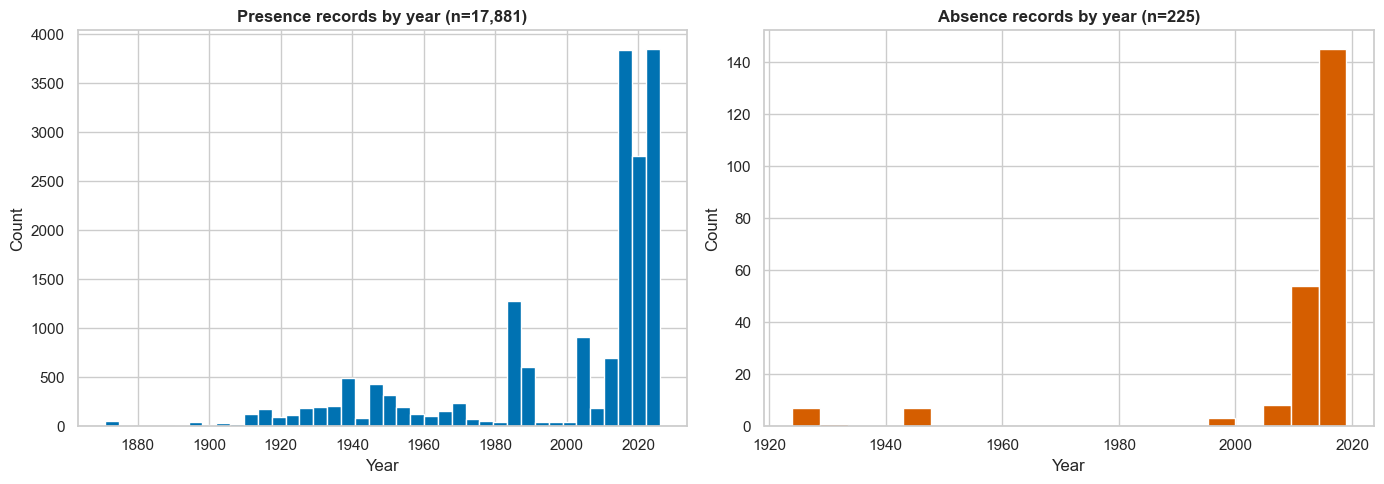

Presence year range: 1871 - 2026 | missing: 68 rows
Absence year range:  1924 - 2019 | missing: 0 rows


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(presence_df['year'].dropna(), bins=40, color=STATUS_COLORS['detected'], edgecolor='white')
axes[0].set_title(f'Presence records by year (n={presence_df["year"].notna().sum():,})')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Count')

axes[1].hist(absence_df['year'].dropna(), bins=20, color=STATUS_COLORS['long absence'], edgecolor='white')
axes[1].set_title(f'Absence records by year (n={absence_df["year"].notna().sum():,})')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Presence year range:', int(presence_df['year'].min()), '-', int(presence_df['year'].max()),
      f'| missing: {presence_df["year"].isna().sum()} rows')
print('Absence year range: ', int(absence_df['year'].min()), '-', int(absence_df['year'].max()),
      f'| missing: {absence_df["year"].isna().sum()} rows')

As expected from the provenance breakdown in Section 5, presence records stretch back to the 1870s (early museum specimens) but are heavily concentrated in the last ~15 years, mirroring the growth of iNaturalist — the histogram even includes observations dated 2026 (this year), consistent with an active, continuously-updated citizen-science feed rather than a data error.

The absence data covers a narrower, older window (1924–2019) and is naturally clustered around the specific years when resurvey fieldwork took place, rather than forming a smooth distribution — it's a designed resurvey dataset, not an opportunistic one.

**Implication for modeling:** presence and absence records are not just spatially mismatched (Section 9) but also temporally mismatched — matching each observation's climate variables to the correct year (rather than a single static climatology) is important, and it's worth checking that the climate columns here were actually extracted per-record-year rather than from a fixed baseline period.

## 9. Spatial Distribution

In [14]:
print('Presence bounding box: lat', presence_df['lat'].min(), '-', presence_df['lat'].max(),
      '| long', presence_df['long'].min(), '-', presence_df['long'].max())
print('Absence bounding box:  lat', absence_df['lat'].min(), '-', absence_df['lat'].max(),
      '| long', absence_df['long'].min(), '-', absence_df['long'].max())

Presence bounding box: lat 34.1986 - 68.96667 | long -149.900278 - -78.699997
Absence bounding box:  lat 37.746133 - 48.50680651 | long -121.9947138 - -114.9810138


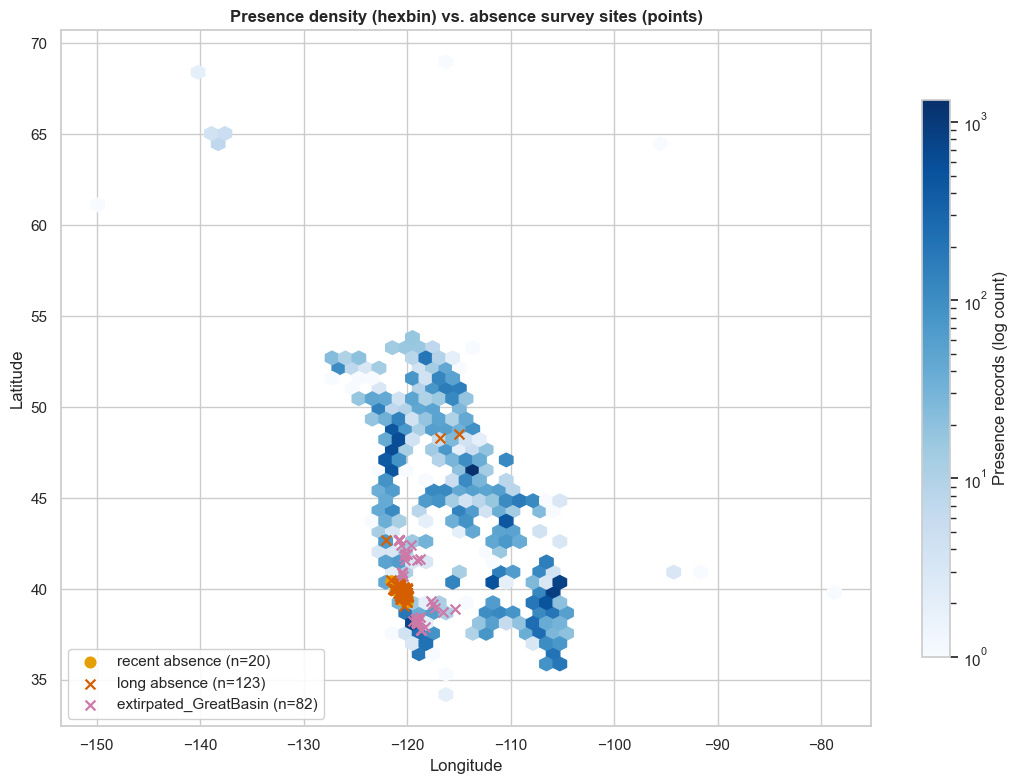

In [15]:
fig, ax = plt.subplots(figsize=(11, 8))

hb = ax.hexbin(presence_df['long'], presence_df['lat'], gridsize=55, cmap='Blues', mincnt=1, bins='log')
plt.colorbar(hb, ax=ax, label='Presence records (log count)', shrink=0.8)

for status in ['recent absence', 'long absence', 'extirpated_GreatBasin']:
    sub = absence_df[absence_df['status_description'] == status]
    ax.scatter(sub['long'], sub['lat'], s=50, marker='o' if status == 'recent absence' else 'x',
               color=STATUS_COLORS[status], label=f'{status} (n={len(sub)})', linewidths=1.6)

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Presence density (hexbin) vs. absence survey sites (points)')
ax.legend(loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.show()

**This is one of the most important data-quality findings in this notebook.** The two files cover very different geographic extents:

- **Presence** spans essentially the whole pika range and beyond — from about 34°N to 69°N and from -150° to -79° longitude, i.e. from Alaska/Yukon down through the Mountain West and out toward the eastern edge of the continent.
- **Absence** is tightly restricted to a single region — roughly 37.7°N–48.5°N, -122°W to -115°W — the Sierra Nevada / Great Basin / northern Rockies corridor (consistent with the `extirpated_GreatBasin` label).

Any presence-vs-absence comparison in this notebook (Section 12 onward) is therefore **confounded by region**: differences we see could reflect true occupancy preference, or they could simply reflect that the absence sites happen to sit in a particular climatic region while presence sites are drawn from everywhere. This is worth keeping in mind throughout, and worth addressing explicitly before modeling (e.g. by restricting comparisons to a shared spatial window, or by using region as a covariate / blocking variable in cross-validation).

Now let's look at elevation, which is one of the strongest known drivers of pika occurrence:

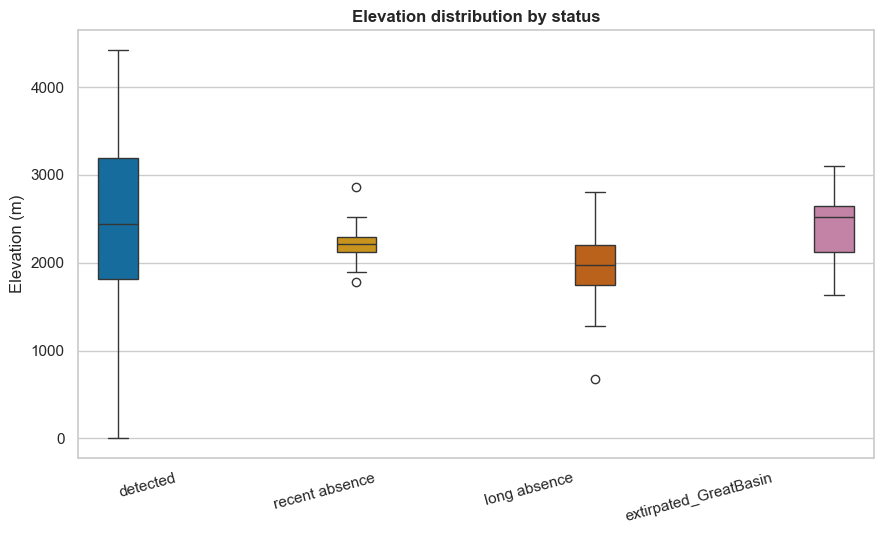

,count,mean,50%,min,max
status_description,,,,,
detected,17011.0,2483.0,2438.4,0.0,4424.0
recent absence,20.0,2216.1,2218.3,1783.0,2865.1
long absence,123.0,1961.4,1973.0,678.0,2801.1
extirpated_GreatBasin,82.0,2415.6,2515.5,1628.0,3106.0


In [16]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=combined_df, x='status_description', y='elevation', order=STATUS_ORDER,
            hue='status_description', palette=STATUS_COLORS, legend=False, ax=ax)
ax.set_title('Elevation distribution by status')
ax.set_xlabel(''); ax.set_ylabel('Elevation (m)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

combined_df.groupby('status_description', observed=True)['elevation'].describe()[['count', 'mean', '50%', 'min', 'max']].round(1)

Elevation tells a more nuanced story than a simple 'presence high, absence low' split. `long absence` sites have the *lowest* median elevation of the four groups (~1,973 m, vs. ~2,438 m for `detected`) — plausible if these were lower-elevation, marginal sites that were never prime pika habitat to begin with, rather than sites where pika were lost. `extirpated_GreatBasin` sites, by contrast, sit at a median elevation (~2,515 m) comparable to — even slightly above — `detected` sites, so elevation alone does not cleanly explain those specific local extinctions; other variables (e.g. the drought/heat measures explored in Section 12) are likely more informative there. `recent absence` sits in between (~2,218 m). As with everything in this section, the regional confound from Section 9 still applies.

## 10. Univariate Analysis — Core Bioclimatic Variables

Distributions below use the presence data, since with ~17,900 records it gives a much more stable picture of the shape of each variable than the 225-row absence file (absence distributions are examined comparatively in Section 12).

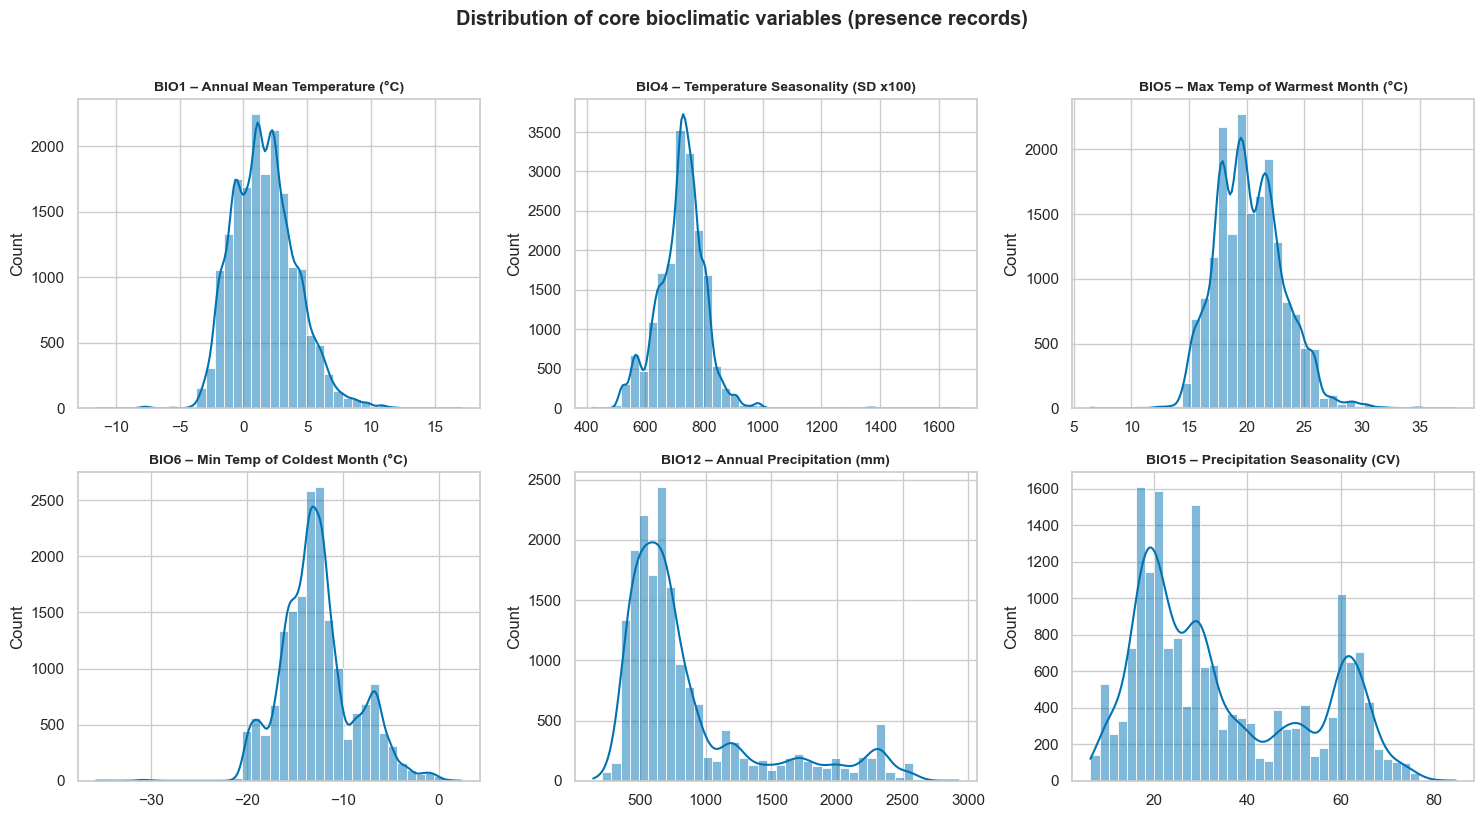

,count,mean,std,min,25%,50%,75%,max
bio1_temp_mean_annual,17947.0,1.67,2.45,-11.54,-0.20,1.51,3.24,17.07
bio4_seasonality_temp,17947.0,722.25,80.71,422.82,675.74,726.54,767.64,1667.54
bio5_temp_max_warm,17947.0,20.25,2.89,6.44,18.09,20.02,22.09,38.12
bio6_temp_min_cold,17947.0,-12.65,3.84,-35.76,-15.10,-13.05,-10.91,2.35
bio12_precip_annual,17947.0,867.66,537.02,143.00,525.00,677.00,928.00,2927.00
bio15_seasonality_precip,17947.0,34.51,18.14,6.41,19.68,29.17,51.30,84.61


In [17]:
bio_vars = {
    'bio1_temp_mean_annual':    'BIO1 – Annual Mean Temperature (°C)',
    'bio4_seasonality_temp':    'BIO4 – Temperature Seasonality (SD x100)',
    'bio5_temp_max_warm':       'BIO5 – Max Temp of Warmest Month (°C)',
    'bio6_temp_min_cold':       'BIO6 – Min Temp of Coldest Month (°C)',
    'bio12_precip_annual':      'BIO12 – Annual Precipitation (mm)',
    'bio15_seasonality_precip': 'BIO15 – Precipitation Seasonality (CV)',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, label) in zip(axes.flat, bio_vars.items()):
    sns.histplot(presence_df[col].dropna(), kde=True, color=STATUS_COLORS['detected'], ax=ax, bins=40)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')
fig.suptitle('Distribution of core bioclimatic variables (presence records)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

presence_df[list(bio_vars.keys())].describe().T.round(2)

- **BIO1** (annual mean temperature) is centered close to freezing (median ≈ 1.5 °C) with almost the entire distribution below 10 °C — consistent with an alpine/subalpine cold-climate specialist.
- **BIO5** (warmest-month max) rarely exceeds the high 20s °C, and **BIO6** (coldest-month min) is almost always well below zero — pika habitat experiences short, cool summers and long, cold winters.
- **BIO12** (annual precipitation) is strongly right-skewed, with a long tail toward wetter maritime sites (up to ~2,900 mm) on top of a typical range in the 500–950 mm band.
- **BIO4** (temperature seasonality) and **BIO15** (precipitation seasonality) both show moderate spread with a right tail, reflecting the mix of maritime and continental mountain climates across the full presence range.

## 11. Univariate Analysis — Snow & Drought (PDSI) Variables

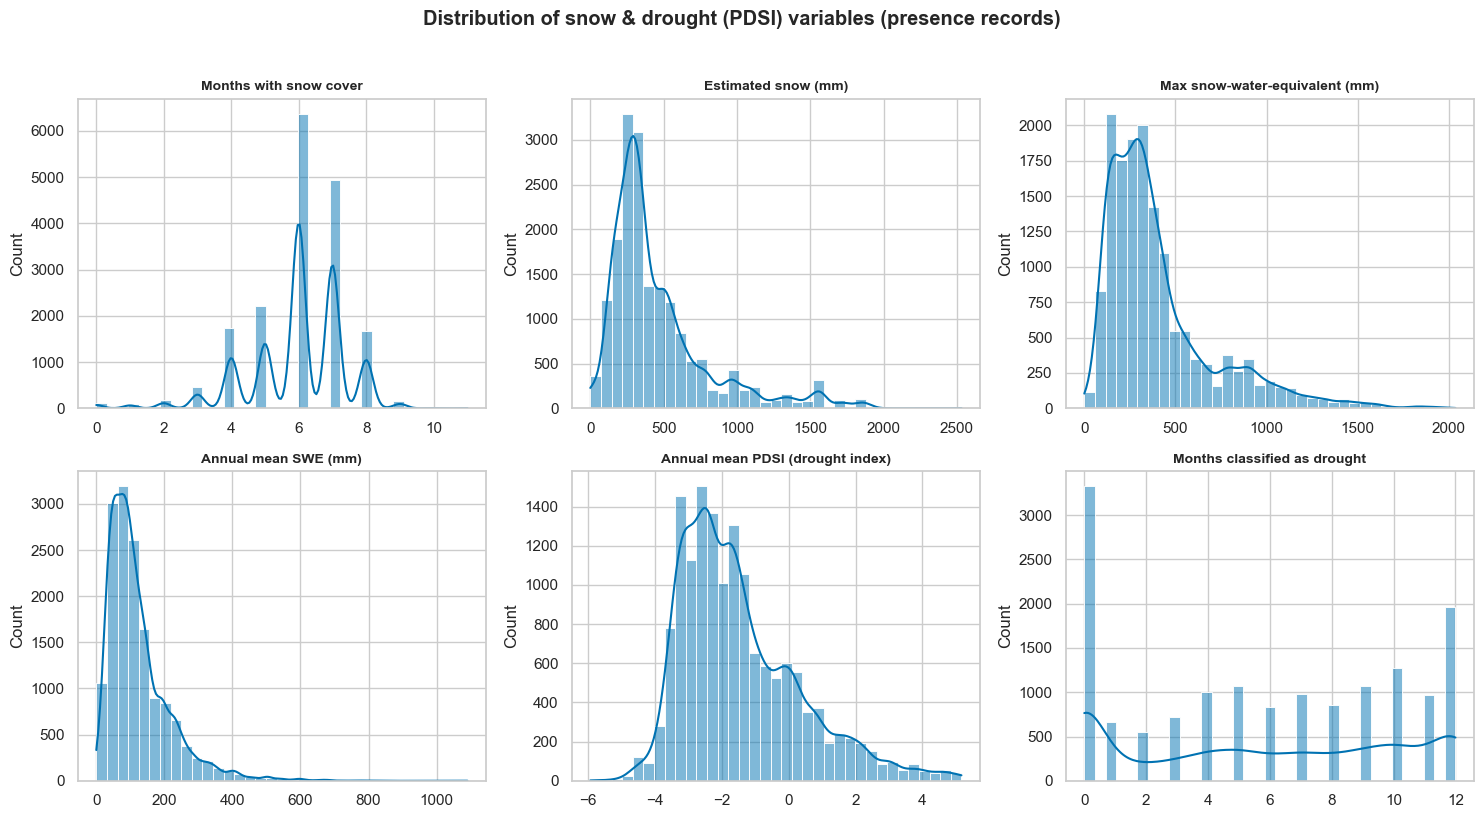

,count,mean,std,min,25%,50%,75%,max
months_with_snow,17948.0,5.99,1.41,0.00,5.00,6.00,7.00,11.00
estim_snow,17947.0,459.76,350.07,0.00,241.00,339.00,548.00,2530.00
Max_snow,15279.0,407.15,306.31,0.00,197.80,318.10,490.60,2035.90
AnnualMean_swe,15279.0,122.50,92.92,0.00,59.79,97.23,152.96,1090.69
AnnualMean_PDSI,15279.0,-1.47,1.80,-5.94,-2.78,-1.84,-0.45,5.17
months_with_drought,15280.0,5.80,4.32,0.00,1.00,6.00,10.00,12.00


In [18]:
snow_drought_vars = {
    'months_with_snow':   'Months with snow cover',
    'estim_snow':         'Estimated snow (mm)',
    'Max_snow':           'Max snow-water-equivalent (mm)',
    'AnnualMean_swe':     'Annual mean SWE (mm)',
    'AnnualMean_PDSI':    'Annual mean PDSI (drought index)',
    'months_with_drought':'Months classified as drought',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, label) in zip(axes.flat, snow_drought_vars.items()):
    sns.histplot(presence_df[col].dropna(), kde=True, color=STATUS_COLORS['detected'], ax=ax, bins=35)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')
fig.suptitle('Distribution of snow & drought (PDSI) variables (presence records)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

presence_df[list(snow_drought_vars.keys())].describe().T.round(2)

PDSI (Palmer Drought Severity Index) is negative on average (median ≈ -1.8), meaning the typical presence site has experienced mild-to-moderate drought conditions historically — PDSI < -2 is conventionally considered at least moderate drought, so a fair share of presence records sit in or near that territory. `months_with_drought` is fairly uniformly spread across its 0–12 range rather than concentrated at one extreme.

The snow variables (`estim_snow`, `Max_snow`, `AnnualMean_swe`) are all right-skewed with long tails toward heavy-snowpack sites, and `months_with_snow` clusters around 5–7 months/year — again consistent with a species tied to persistent montane snowpack (both as insulation for winter burrows and as a summer water source).

## 12. Presence vs. Absence — Statistical Comparison

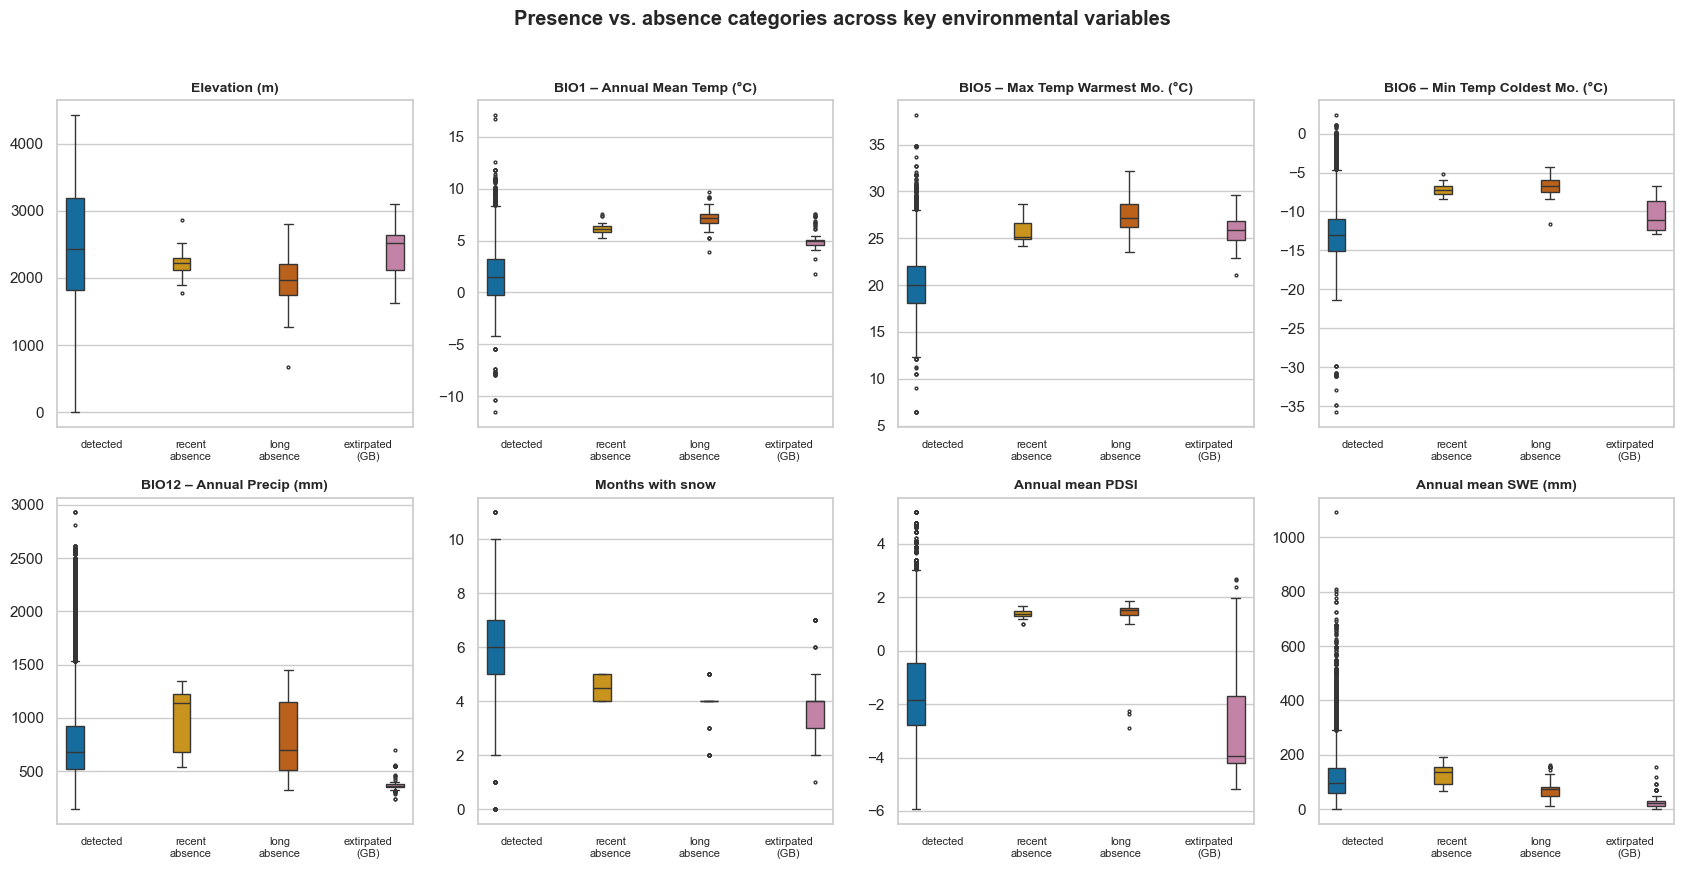

In [19]:
compare_vars = {
    'elevation':             'Elevation (m)',
    'bio1_temp_mean_annual': 'BIO1 – Annual Mean Temp (°C)',
    'bio5_temp_max_warm':    'BIO5 – Max Temp Warmest Mo. (°C)',
    'bio6_temp_min_cold':    'BIO6 – Min Temp Coldest Mo. (°C)',
    'bio12_precip_annual':   'BIO12 – Annual Precip (mm)',
    'months_with_snow':      'Months with snow',
    'AnnualMean_PDSI':       'Annual mean PDSI',
    'AnnualMean_swe':        'Annual mean SWE (mm)',
}

fig, axes = plt.subplots(2, 4, figsize=(17, 8.5))
for ax, (col, label) in zip(axes.flat, compare_vars.items()):
    sns.boxplot(data=combined_df, x='status_description', y=col, order=STATUS_ORDER,
                hue='status_description', palette=STATUS_COLORS, legend=False, ax=ax, fliersize=2)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(['detected', 'recent\nabsence', 'long\nabsence', 'extirpated\n(GB)'], fontsize=8)
fig.suptitle('Presence vs. absence categories across key environmental variables', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

A formal (non-parametric) test backs up what the boxplots suggest. Since sample sizes and variances differ hugely between classes, a Mann–Whitney U test (presence vs. **all** absence records combined) is more appropriate here than a t-test:

In [20]:
pres = combined_df[combined_df['dataset'] == 'presence']
abse = combined_df[combined_df['dataset'] == 'absence']

rows = []
for col, label in compare_vars.items():
    p = pres[col].dropna()
    a = abse[col].dropna()
    u, pval = stats.mannwhitneyu(p, a, alternative='two-sided')
    rows.append({
        'variable': label,
        'presence_median': p.median(),
        'absence_median': a.median(),
        'presence_n': len(p),
        'absence_n': len(a),
        'p_value': pval,
        'significant (a=0.05)': pval < 0.05,
    })

mwu_results = pd.DataFrame(rows).set_index('variable').round(4)
mwu_results

,presence_median,absence_median,presence_n,absence_n,p_value,significant (a=0.05)
variable,,,,,,
Elevation (m),2438.4000,2136.0384,17011,225,0.0,True
BIO1 – Annual Mean Temp (°C),1.5137,6.4735,17947,225,0.0,True
BIO5 – Max Temp Warmest Mo. (°C),20.0200,26.6480,17947,225,0.0,True
BIO6 – Min Temp Coldest Mo. (°C),-13.0520,-7.5280,17947,225,0.0,True
BIO12 – Annual Precip (mm),677.0000,539.0000,17947,225,0.0,True
Months with snow,6.0000,4.0000,17948,225,0.0,True
Annual mean PDSI,-1.8375,1.3200,15279,210,0.0,True
Annual mean SWE (mm),97.2333,66.4833,15279,210,0.0,True


Every variable tested comes back statistically significant — unsurprising given presence alone has ~18,000 points, so even small differences reach significance easily. The more useful signal is the **direction and size** of the median gap: presence sites are, on average, colder (lower BIO1/BIO5, lower/more negative BIO6), snowier (more months with snow, higher SWE), and somewhat wetter (higher BIO12) than absence sites, which lines up with pika's known dependence on cool, snow-buffered microhabitats.

**But — the caveat from Section 9 applies directly here.** Because the absence sample is geographically confined to the Great Basin/Sierra corridor while presence is continent-wide, part of every one of these gaps could be a *regional* climate difference rather than a *pika-preference* difference. Before trusting these variables as strong SDM predictors, it would be worth re-running this comparison restricted to presence points that fall inside (or near) the absence data's bounding box, to separate a general "colder/snowier regional climate" effect from a "pikas specifically avoid the warmer, less snowy sites within their own region" effect.


## 13. Correlation Structure

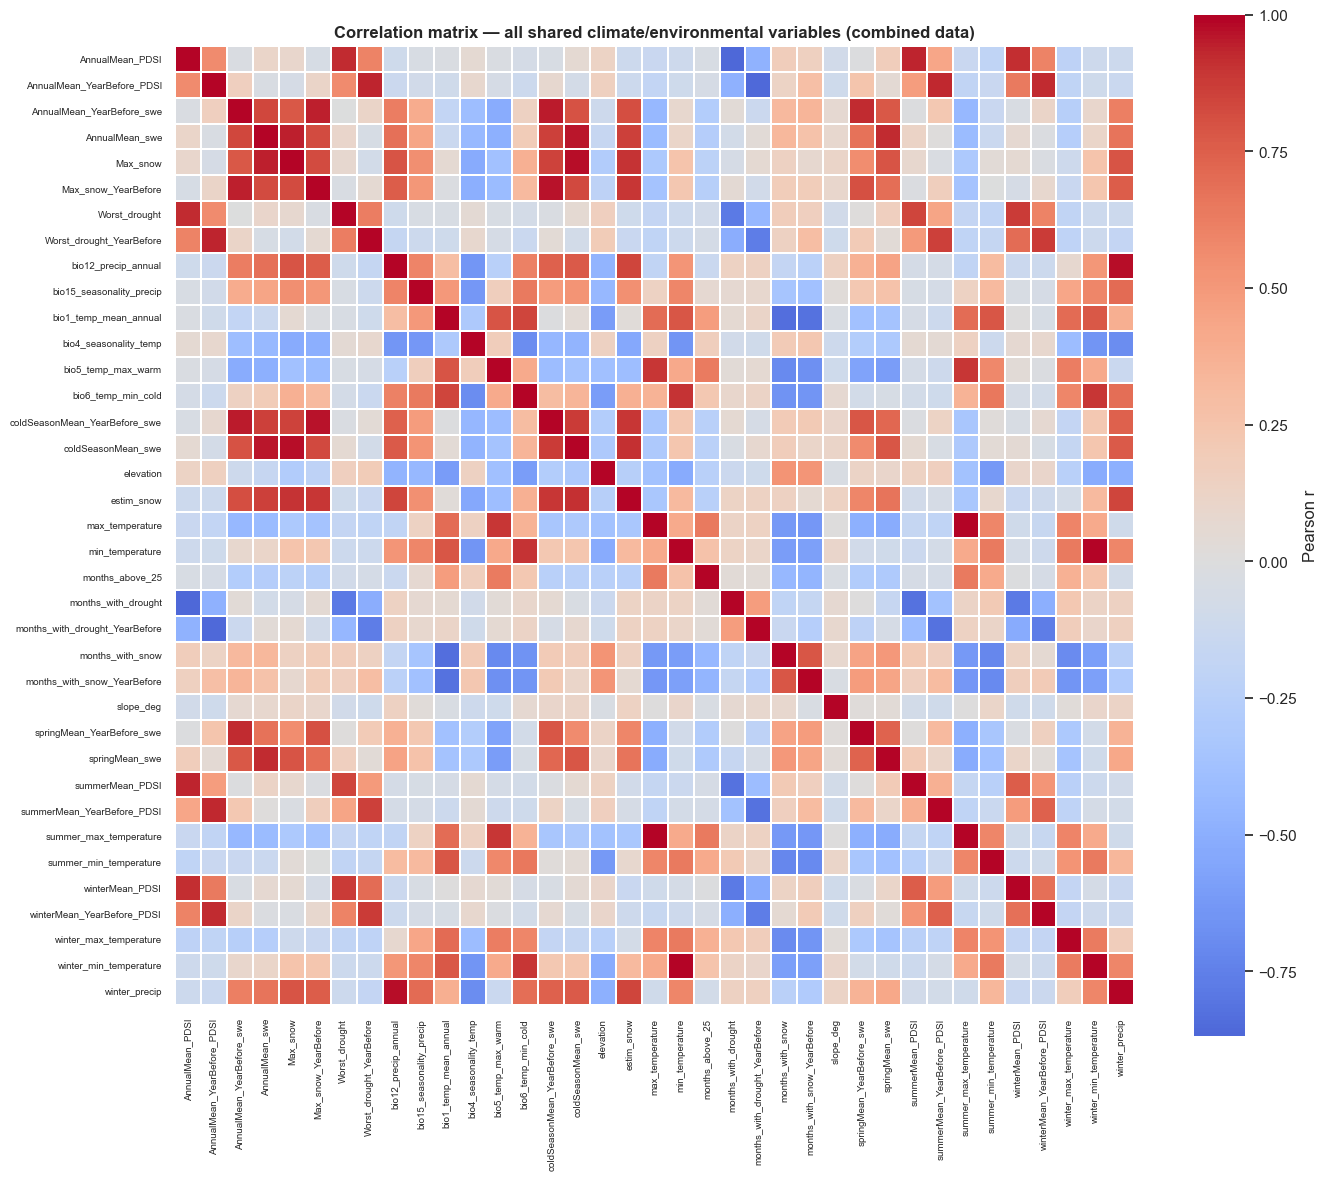

In [21]:
exclude = ['id', 'lat', 'long', 'year', 'status', 'status_description']
climate_vars = [c for c in shared_cols if c not in exclude]

corr = combined_df[climate_vars].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, linewidths=0.3,
            cbar_kws={'label': 'Pearson r'}, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('Correlation matrix — all shared climate/environmental variables (combined data)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

In [22]:
corr_pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
top_corr = corr_pairs[corr_pairs.abs() > 0.85].sort_values(key=abs, ascending=False)
top_corr.to_frame('pearson_r').round(3)

pearson_r
max_temperature               summer_max_temperature              1.000
min_temperature               winter_min_temperature              0.997
bio12_precip_annual           winter_precip                       0.976
Max_snow                      coldSeasonMean_swe                  0.972
Max_snow_YearBefore           coldSeasonMean_YearBefore_swe       0.967
AnnualMean_swe                coldSeasonMean_swe                  0.959
AnnualMean_YearBefore_swe     coldSeasonMean_YearBefore_swe       0.956
                              Max_snow_YearBefore                 0.948
AnnualMean_swe                Max_snow                            0.944
AnnualMean_YearBefore_PDSI    Worst_drought_YearBefore            0.940
AnnualMean_PDSI               summerMean_PDSI                     0.939
AnnualMean_YearBefore_PDSI    summerMean_YearBefore_PDSI          0.930
AnnualMean_PDSI               Worst_drought                       0.927
AnnualMean_YearBefore_swe     springMean_YearBefore_swe           0.924
AnnualMean_YearBefore_PDSI    winterMean_YearBefore_PDSI          0.922
AnnualMean_swe                springMean_swe                      0.922
AnnualMean_PDSI               winterMean_PDSI                     0.917
coldSeasonMean_swe            estim_snow                          0.911
Max_snow                      estim_snow                          0.905
bio6_temp_min_cold            min_temperature                     0.902
                              winter_min_temperature              0.898
bio5_temp_max_warm            max_temperature                     0.897
                              summer_max_temperature              0.896
coldSeasonMean_YearBefore_swe estim_snow                          0.893
Max_snow_YearBefore           estim_snow                          0.891
Worst_drought                 winterMean_PDSI                     0.883
Worst_drought_YearBefore      winterMean_YearBefore_PDSI          0.883
coldSeasonMean_YearBefore_swe coldSeasonMean_swe                  0.878
AnnualMean_PDSI               months_with_drought                -0.868
AnnualMean_swe                coldSeasonMean_YearBefore_swe       0.860
                              estim_snow                          0.859
AnnualMean_YearBefore_PDSI    months_with_drought_YearBefore     -0.858
Worst_drought_YearBefore      summerMean_YearBefore_PDSI          0.857

The heatmap shows several tightly-correlated blocks rather than 37 independent axes of variation:

- **Temperature family** — `bio1`, `bio5`, `bio6`, `max_temperature`, `min_temperature`, and their summer/winter splits move together closely, since they're all different summaries of the same underlying temperature signal.
- **Snow/SWE family** — `estim_snow`, `Max_snow`, `AnnualMean_swe`, `coldSeasonMean_swe`, and `months_with_snow` are strongly intercorrelated.
- **"Current year" vs. "year before" pairs** (e.g. `AnnualMean_PDSI` vs. `AnnualMean_YearBefore_PDSI`, `Max_snow` vs. `Max_snow_YearBefore`) are moderately-to-strongly correlated (r roughly in the 0.5–0.85 range in this data) — expected, since regional climate persists somewhat year to year, but not so redundant that the lagged versions carry zero extra information.

**Implication:** feeding all ~37 variables into a linear or distance-based model as-is invites multicollinearity problems. Tree-based ensembles (Random Forest, XGBoost) tolerate correlated features reasonably well, but even there, trimming to one representative per correlated cluster (or using PCA / feature-importance-based pruning) would likely give a cleaner, more interpretable model.

## 14. Pairwise Relationships

A pairplot over every presence record (~17,900 points) would be unreadable and slow to render, so presence is randomly subsampled to 1,500 points for this plot only; all 225 absence points are kept.

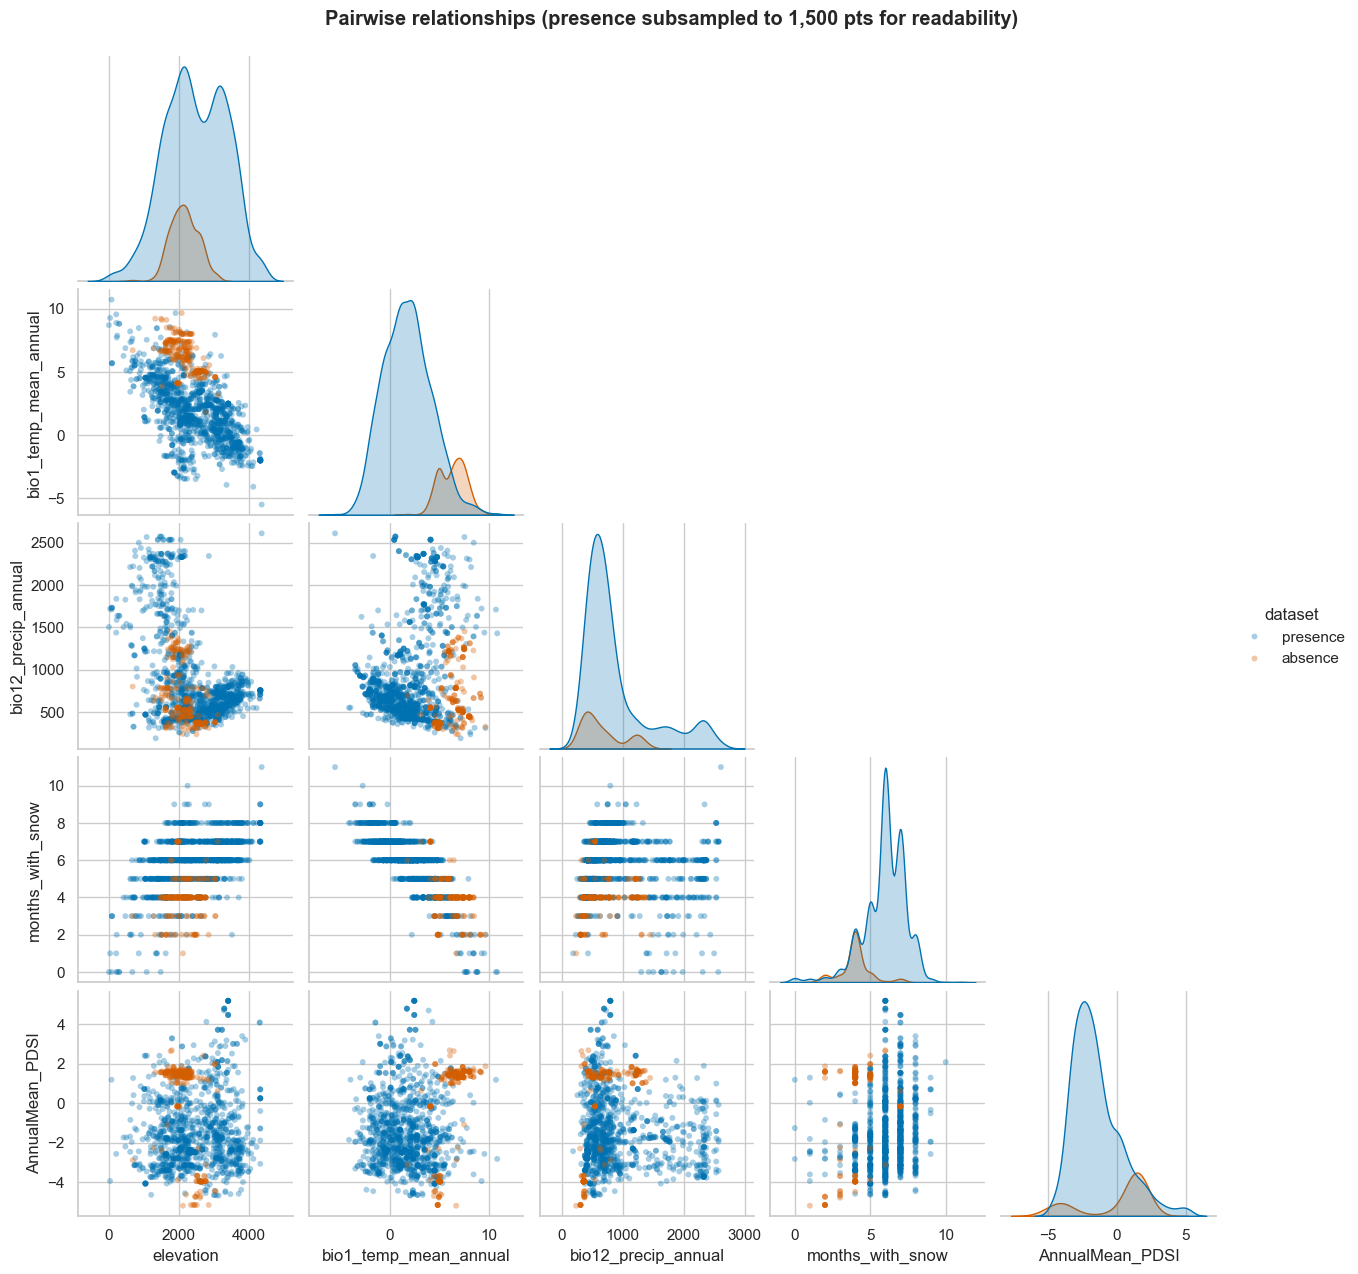

In [23]:
pair_vars = ['elevation', 'bio1_temp_mean_annual', 'bio12_precip_annual', 'months_with_snow', 'AnnualMean_PDSI']

presence_sample = presence_labeled.sample(n=1500, random_state=42)
pairplot_df = pd.concat([presence_sample, absence_labeled], ignore_index=True)

g = sns.pairplot(pairplot_df, vars=pair_vars, hue='dataset', palette=DATASET_COLORS,
                  plot_kws=dict(alpha=0.35, s=18, linewidth=0), diag_kind='kde', corner=True)
g.fig.suptitle('Pairwise relationships (presence subsampled to 1,500 pts for readability)', y=1.02, fontweight='bold')
plt.show()

Elevation and `bio1` (annual mean temperature) show the clearest, cleanest relationship in the panel — a tight negative correlation, exactly as expected from the environmental lapse rate (temperature drops ~6.5 °C per 1,000 m of elevation gain). `AnnualMean_PDSI` and `bio12` (precipitation) show more scatter/noise, and the absence points (orange) sit in a visibly narrower cloud than the presence points (blue) — a direct visual echo of the geographic-extent mismatch discussed in Section 9: absence sites simply don't span the same range of conditions that presence sites do.

## 15. Outliers & Data-Quality Deep Dive

In [24]:
def iqr_outlier_share(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).mean() * 100

numeric_shared = [c for c in shared_cols
                   if pd.api.types.is_numeric_dtype(presence_df[c]) and c not in ['lat', 'long', 'year', 'status']]

outlier_pct = pd.Series({c: iqr_outlier_share(presence_df[c]) for c in numeric_shared}).sort_values(ascending=False)
outlier_pct.head(12).round(1).to_frame('presence: outlier share % (1.5x IQR rule)')

,presence: outlier share % (1.5x IQR rule)
bio12_precip_annual,13.7
winter_precip,12.6
months_above_25,11.2
Worst_drought_YearBefore,10.9
coldSeasonMean_swe,9.9
months_with_snow_YearBefore,9.5
estim_snow,8.2
coldSeasonMean_YearBefore_swe,8.2
Max_snow_YearBefore,8.1
Max_snow,7.7


A handful of variables (drought/PDSI extremes, seasonality measures) show a non-trivial share of statistical outliers by the standard 1.5×IQR rule — expected for climate data, since droughts and seasonality *are* inherently tail-heavy phenomena, so this is more a flag for awareness (e.g. consider robust scalers) than necessarily a data-cleaning target.

A more concrete data-quality issue is elevation values of exactly `0.0`, which is implausible for an alpine specialist and more likely a sentinel for a failed elevation lookup (e.g. a coordinate that fell outside the DEM raster) than a genuine sea-level record:

In [25]:
zero_elev = presence_df[presence_df['elevation'] == 0.0]
print(f'{len(zero_elev)} presence rows have elevation == 0.0  ({len(zero_elev)/len(presence_df):.2%} of presence data)')
zero_elev[['id', 'lat', 'long', 'year', 'elevation']].head(10)

36 presence rows have elevation == 0.0  (0.20% of presence data)


,id,lat,long,year,elevation
342,125b3d26-2832-8324-05bc-072b4a4ddc25,65.0833,-138.217,1977.0,0.0
389,12ecfd37-42c1-2c14-479f-eb5734928769,64.6667,-138.383,1977.0,0.0
661,16077d25-8ec3-ec34-979d-bded7c88d578,51.4667,-127.583,1937.0,0.0
1020,1be77e29-015e-15e4-80b1-735bc8062f04,50.4833,-125.050,1936.0,0.0
1307,2283ced6-0c4a-c4a4-8b96-399f2de67bc0,50.4833,-125.050,1936.0,0.0
1376,27763fa1-c82f-82f4-5d9f-33f90c5ab78b,65.0833,-138.217,1977.0,0.0
1425,2ecd7b04-8ade-ade4-74bd-d0c22adb61b8,65.0833,-138.267,1977.0,0.0
1766,34c2dcb3-5f2b-f2b4-2395-aa0090c70807,65.0833,-138.217,1977.0,0.0
1881,35e1828d-0035-0354-aebc-dbed31235246,64.5500,-138.250,1977.0,0.0
2155,40f5a4ef-14a7-4a74-f5ad-7e33c1f5c0d1,50.4833,-125.050,1936.0,0.0


These rows cluster geographically at the extreme edges of the presence bounding box seen in Section 9 (e.g. the northernmost/southeasternmost points) — consistent with coordinates landing outside the elevation raster's coverage rather than 36 real sea-level pika sightings. The safest treatment is to recode `elevation == 0.0` as missing (`NaN`) rather than a valid value before any modeling that uses elevation.

## 16. Summary of Key Findings

**Class balance**
- ~80 presence records for every 1 absence record (17,949 vs. 225). Any model needs explicit handling for this (class weights, pseudo-absences, or resampling) and a metric more informative than accuracy (e.g. AUC, F1, balanced accuracy).

**Geographic & temporal mismatch (the most important caveat)**
- Presence spans nearly the full pika range and beyond (34–69°N); absence is confined to the Sierra Nevada/Great Basin corridor (37.7–48.5°N). Every presence-vs-absence comparison in this notebook is potentially confounded by this regional mismatch.
- Presence records span 1871–2026 and skew heavily toward the post-2008 iNaturalist era; absence records span 1924–2019 and cluster around specific resurvey campaigns. Matching each record's climate features to its own year (not a fixed climatology) matters here.

**Missing data**
- `patch_size`, `units`, `slope` (presence-only) are ~89–100% empty — not usable as-is.
- The supplementary PDSI/drought/snow block is missing in ~15% of presence rows and ~7% of absence rows, in a pattern that looks record-level (whole rows falling outside supplementary-layer coverage) rather than random.
- Core BIO1–BIO15, `months_with_snow`, `estim_snow`, and `winter_precip` are essentially complete.

**Data quality**
- 36 presence rows (~0.2%) have `elevation == 0.0`, almost certainly a failed-lookup sentinel rather than genuine sea-level habitat; recode to `NaN` before use.
- No full-row duplicates and no `id` overlap between the two files. Absence `id` duplication (68 rows) reflects legitimate repeat site visits.
- Presence data aggregates multiple sources (mainly iNaturalist and the Arctos museum network) — worth keeping in mind for source-specific biases (citizen-science observations skew toward accessible, popular locations).

**Environmental signal**
- Presence sites are colder, snowier, and somewhat wetter than absence sites (Mann–Whitney significant for all 8 variables tested), matching pika's known cold/snowpack dependence — but interpret cautiously given the regional confound above.
- Elevation and BIO1 (temperature) are tightly, almost mechanically correlated, and there are broader correlated "families" (temperature metrics; snow/SWE metrics; current-year vs. year-before drought/snow pairs). A feature-selection or dimensionality-reduction step is advisable before fitting models sensitive to multicollinearity.

**Suggested next steps**
1. Recode `elevation == 0.0` (and check other variables for similar sentinel values) as missing.
2. Decide an explicit strategy for the ~15% missing supplementary variables (imputation vs. a model that handles NaNs natively).
3. Address the presence/absence spatial mismatch — at minimum, re-run the Section 12 comparisons restricted to a shared geographic window, and consider spatial blocking in any cross-validation scheme.
4. Reduce redundancy among the ~37 correlated environmental variables before modeling (drop, combine, or apply PCA to the most collinear clusters).
5. Plan an explicit imbalance-handling strategy (pseudo-absence generation, class weighting, or resampling) given the ~80:1 ratio.